In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Program 1

In [6]:
# normalized gaussian distribution
n = 1000000
x_bar = 0
sigma = 1.0
samples = np.random.normal(x_bar, sigma, n)
for i in range(5):
    p1sigma = np.mean(abs(samples) <= (i+1)*sigma)
    print(f"P(|x| <= {i+1} sigma) = {p1sigma*100:.2f}%")

P(|x| <= 1 sigma) = 68.28%
P(|x| <= 2 sigma) = 95.47%
P(|x| <= 3 sigma) = 99.73%
P(|x| <= 4 sigma) = 99.99%
P(|x| <= 5 sigma) = 100.00%


### Problem 2

In [34]:
nx = ny = 10000000
a = -20
b = 20
x = np.linspace(a,b,nx)
y = np.linspace(a,b,ny)
fx = np.exp(-(x**2))
fy = np.exp(-(y**2))
I = np.sum(0.5*np.diff(y)*(fy[1:]+fy[:-1]))
I *= np.sum(0.5*np.diff(x)*(fx[1:]+fx[:-1]))
print(I)
print(np.pi)

3.1415926535897927
3.141592653589793


### Problem 3

In [34]:
# lagrange interpolation
def lagrange_interpolation(x_data, y_data, n, x):
    P = 0.0

    for k in range(n):
        lk = 1.0
        for j in range(n):
            if j != k:
                lk *= (x-x_data[j]) / (x_data[k] - x_data[j])
        P += y_data[k] * lk
    
    return P    

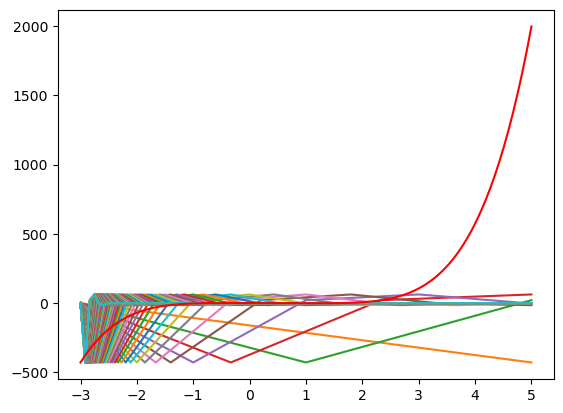

In [58]:
d = []
for n in range(100):
    x = 1.2
    x_data = np.linspace(-3,5, n+1)
    
    y_data = []
    for i in range(n+1):
        y_data.append(x_data[i]**5 - 2*x_data[i]**4 + x_data[i]**3 - x_data[i] + 1) 
    
    d.append(float(lagrange_interpolation(x_data, y_data, n, x)))
    plt.plot(x_data, d)
    #print(d)    
 
plt.plot(x_data, y_data, color = 'red')

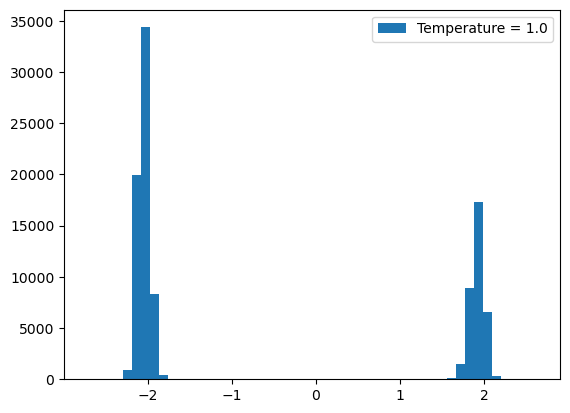

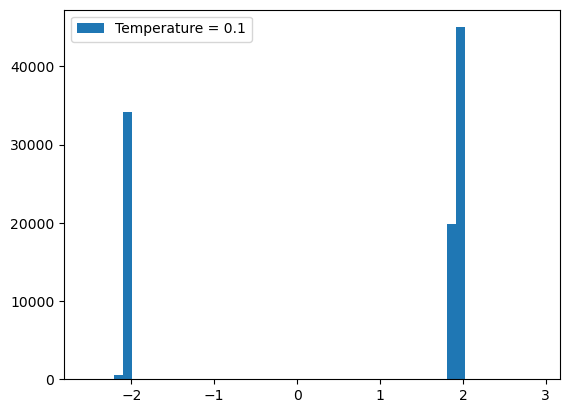

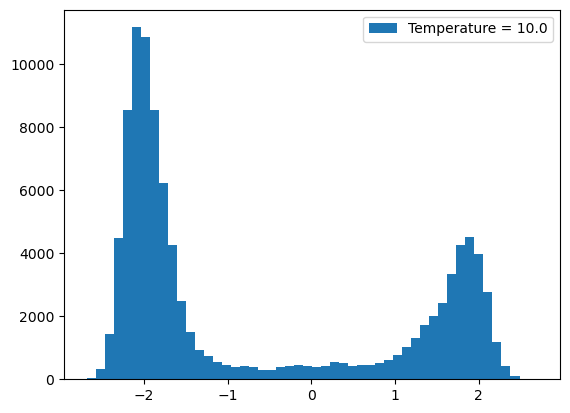

In [9]:
# Define function
def f(x):
    return x**6 - 6*x**4 + x**3 + 1

n = 100000
b =20
temp = [1.0,0.1,10.0]

for t in temp:
    x_traj = []
    for j in range(b):
        x = np.random.uniform(-3,3)
        for i in range(int(n/b)):
            x_trail = x + 0.1*(2*np.random.rand()-1)
            if f(x_trail)<f(x):
                x = x_trail
            else:
                if np.random.rand()<np.exp(-(f(x_trail)-f(x))/t):
                    x = x_trail
            x_traj.append(x)
    counts, bin_edges, _ = plt.hist(x_traj, bins=100)
    peaks = []
    for i in range(1, len(counts)-1):
        if counts[i]>(n/200):
            if counts[i] > counts[i-1] and counts[i] > counts[i+1]:
                peaks.append(i)
    peaks = list(set(peaks))        
    plt.figure()    
    plt.hist(x_traj, bins = 50, label = f'Temperature = {t}')
    plt.legend()
    plt.show()

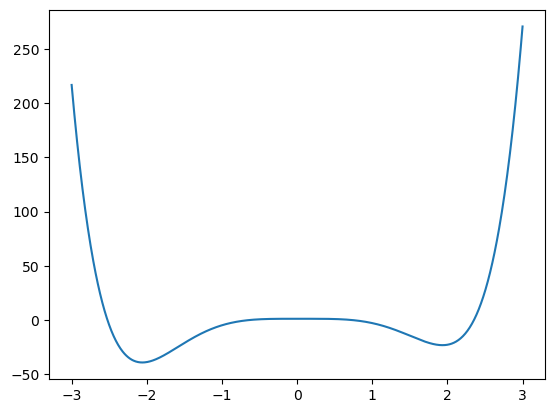

In [7]:
plt.plot(np.linspace(-3,3,1000),f(np.linspace(-3,3,1000)))